# Caso CPS: ¿Qué Impulsa los Ingresos?
## Análisis visual de los drivers de income — Metodología "De Modelos de ML a Estrategia" (IPADE)

**Materia:** Progressive Digital Marketing — MEDE 2024-2026
**Dataset:** Current Population Survey, marzo 2009 (`cps09mar.csv`)
**Objetivo:** **Explicar y entender** qué variables demográficas y laborales explican las diferencias de ingreso. *No predecir, interpretar.*

---

### Estructura del notebook

1. **Planteamiento del problema de negocio**
2. **EDA visual exhaustivo** — entender la data antes de modelar
3. **Limpieza con antes/después visual**
4. **Feature engineering visualizado**
5. **Modelaje** (5 modelos) — cada uno con sus propios diagnósticos visuales
6. **Evaluación comparativa visual** — múltiples ángulos
7. **Interpretación visual completa** — FI, PDP, SHAP global y local
8. **Estrategia y conclusiones**

---


## 1. Planteamiento del problema

### 1.1 La pregunta de negocio

> **¿Existe una relación entre el ingreso de un individuo y sus variables demográficas y laborales? ¿Cuáles variables explican mejor las diferencias de ingreso, y en qué dirección?**

Relevante para:
- **HR / Total Rewards:** detectar brechas inequitativas controlando por factores legítimos.
- **Marketing:** segmentación de poder adquisitivo.
- **Políticas públicas:** entender drivers de desigualdad económica.

### 1.2 Los datos: 50,742 individuos × 12 variables

`cps09mar.csv` — extracto del Current Population Survey marzo 2009 (full-time workers, no militares).

| Variable | Tipo | Descripción |
|---|---|---|
| `age` | continua | Edad (tope 85) |
| `female` | binaria | 1 = mujer |
| `hisp` | binaria | 1 = hispano/latino |
| `education` | ordinal | 0–20 (años aprox. de educación) |
| `earnings` | **target** | Ingreso anual USD |
| `hours` | continua | Horas/semana |
| `week` | continua | Semanas/año |
| `union` | binaria | 1 = miembro sindicato |
| `uncov` | binaria | 1 = cubierto por contrato sindical |
| `region` | nominal | 1=NE, 2=MW, 3=S, 4=W |
| `race` | nominal | 1–21 (lo agruparemos) |
| `marital` | nominal | 1–7 (estado civil) |

### 1.3 Enfoque

- **Variable objetivo:** `log(earnings)` → regresión.
- **¿Por qué log?** Ingresos están muy sesgados a la derecha. El log normaliza la distribución y los coeficientes se vuelven "% de cambio en ingreso", lenguaje gerencial.
- **¿Por qué varios modelos?** Cada uno aporta una pieza distinta de la historia: OLS da coeficientes interpretables con p-values (lo que pide la nota IPADE), Lasso selecciona variables, el árbol da reglas legibles, Random Forest captura no-linealidades, Gradient Boosting es el benchmark de rendimiento.

> 📌 **Recordatorio IPADE:** importancia ≠ causalidad. Los modelos describen asociaciones, no causas.


## 2. EDA visual exhaustivo

Antes de tocar cualquier modelo, vamos a **mirar los datos con calma**. La meta de esta sección es que para el final tengas una intuición fuerte de qué está pasando.


In [33]:
# Imports y configuración
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo consistente
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 95
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Paleta consistente
PALETTE = {
    'primary':   '#2E86AB',
    'secondary': '#A23B72',
    'success':   '#06A77D',
    'warning':   '#F18F01',
    'danger':    '#C73E1D',
    'neutral':   '#6C757D'
}

RANDOM_STATE = 42

# Cargar datos
df = pd.read_csv('cps09mar.csv')
print(f"✓ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

✓ Dataset cargado: 50,742 filas × 12 columnas


,age,female,hisp,education,earnings,hours,week,union,uncov,region,race,marital
0,52,0,0,12,146000,45,52,0,0,1,1,1
1,38,0,0,18,50000,45,52,0,0,1,1,1
2,38,0,0,14,32000,40,51,0,0,1,1,1
3,41,1,0,13,47000,40,52,0,0,1,1,1
4,42,0,0,13,161525,50,52,1,0,1,1,1


### 2.1 Panorámica general — un solo vistazo a TODO

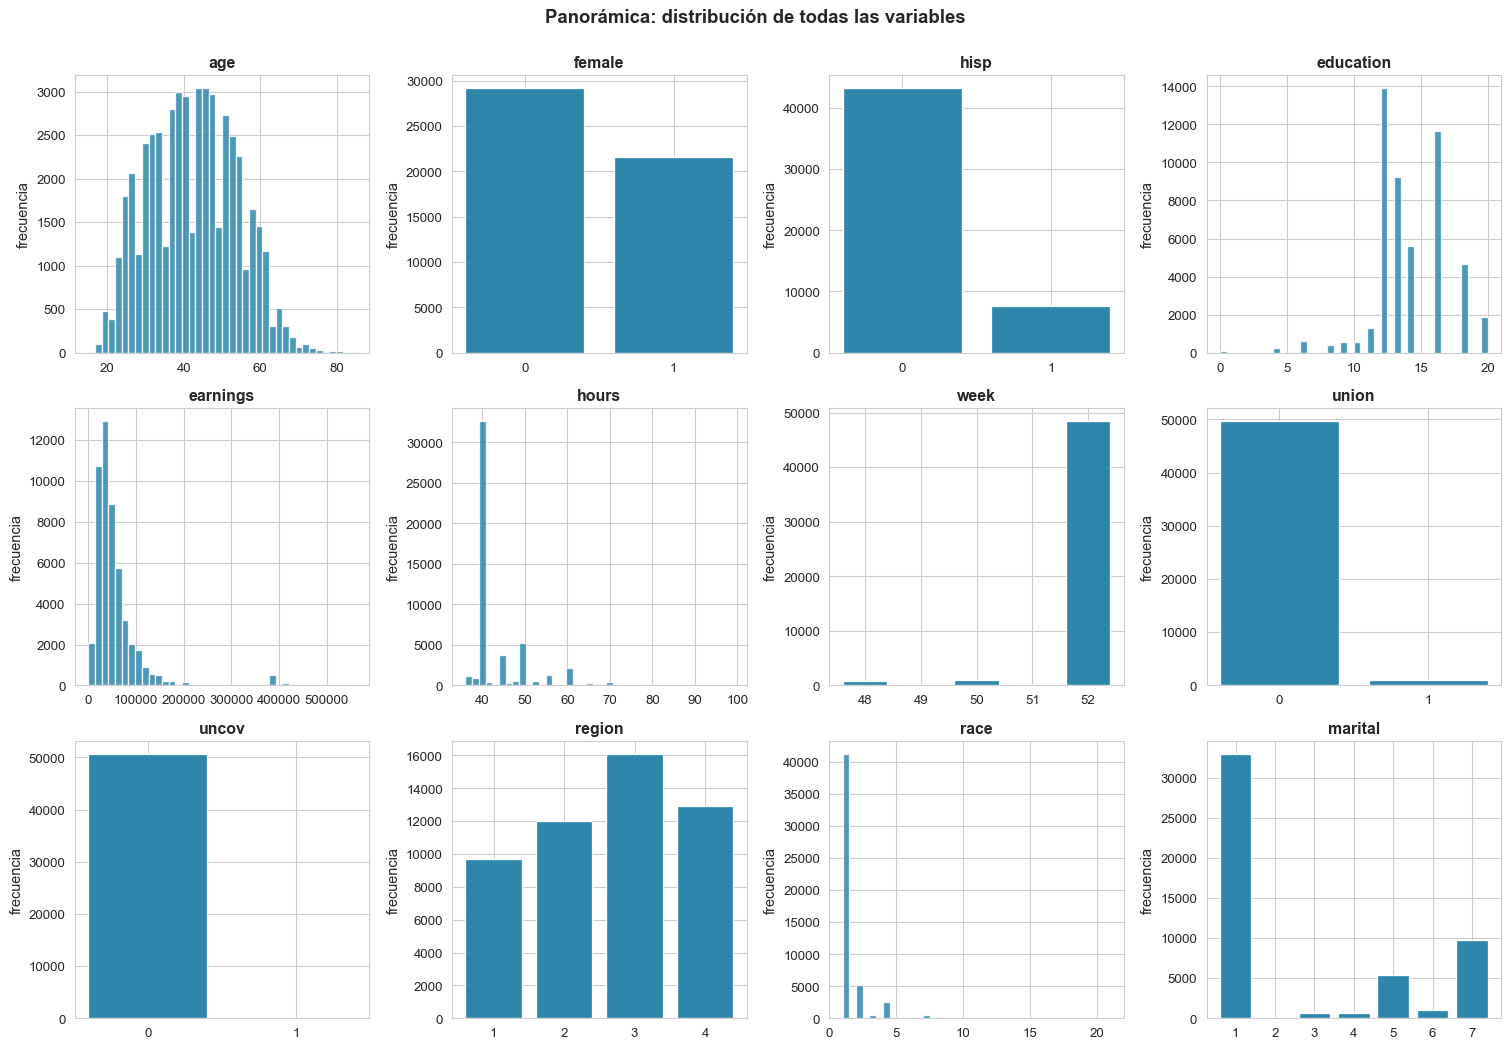

In [34]:
# Vista panorámica: distribución de TODAS las variables a la vez
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Panorámica: distribución de todas las variables', fontsize=14, fontweight='bold', y=1.00)

for ax, col in zip(axes.flat, df.columns):
    if df[col].nunique() <= 10:
        # Variables categóricas / binarias / pocos valores
        counts = df[col].value_counts().sort_index()
        ax.bar(range(len(counts)), counts.values, color=PALETTE['primary'], edgecolor='white')
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, rotation=0)
    else:
        # Variables continuas
        ax.hist(df[col], bins=40, color=PALETTE['primary'], edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('frecuencia')

plt.tight_layout()
plt.show()

**Lo que se ve de un vistazo:**
- `earnings` tiene una cola larga a la derecha (asimetría fuerte).
- `education` es ordinal con concentración en 12 (high school) y 16 (bachelor's).
- `age` está bien distribuida.
- `female`, `hisp`, `union`, `uncov` están desbalanceadas (mayoría negativa).
- `race` está dominada por una sola categoría (white).


### 2.2 La variable objetivo en profundidad

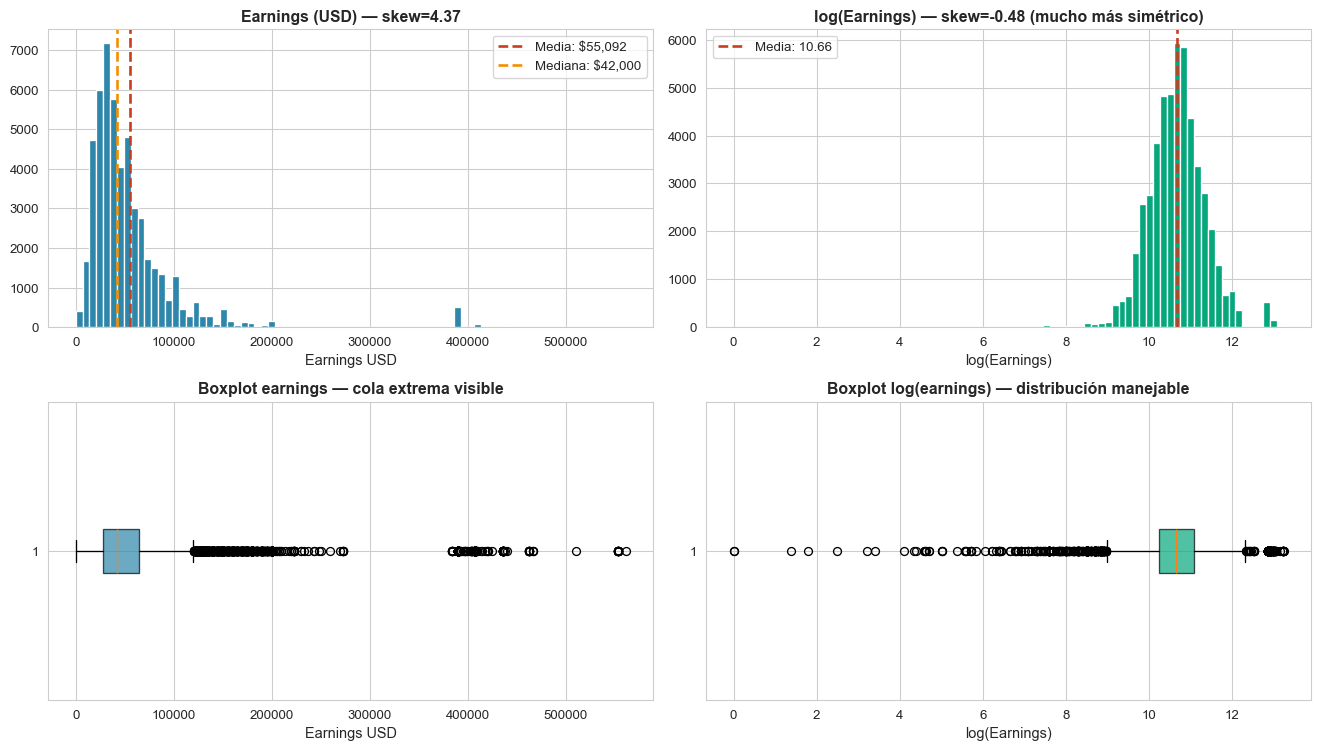

Earnings: min=$1, max=$561,087
P5=$15,000, P95=$125,285


In [35]:
# Earnings: original vs log, con estadísticas
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Histograma original
axes[0,0].hist(df['earnings'], bins=80, color=PALETTE['primary'], edgecolor='white')
axes[0,0].axvline(df['earnings'].mean(), color=PALETTE['danger'], linestyle='--', linewidth=2, label=f"Media: ${df['earnings'].mean():,.0f}")
axes[0,0].axvline(df['earnings'].median(), color=PALETTE['warning'], linestyle='--', linewidth=2, label=f"Mediana: ${df['earnings'].median():,.0f}")
axes[0,0].set_title(f'Earnings (USD) — skew={df["earnings"].skew():.2f}', fontweight='bold')
axes[0,0].set_xlabel('Earnings USD')
axes[0,0].legend()

# Histograma log
log_earn = np.log(df['earnings'])
axes[0,1].hist(log_earn, bins=80, color=PALETTE['success'], edgecolor='white')
axes[0,1].axvline(log_earn.mean(), color=PALETTE['danger'], linestyle='--', linewidth=2, label=f'Media: {log_earn.mean():.2f}')
axes[0,1].set_title(f'log(Earnings) — skew={log_earn.skew():.2f} (mucho más simétrico)', fontweight='bold')
axes[0,1].set_xlabel('log(Earnings)')
axes[0,1].legend()

# Boxplot original (para ver outliers)
axes[1,0].boxplot(df['earnings'], vert=False, patch_artist=True,
                   boxprops=dict(facecolor=PALETTE['primary'], alpha=0.7))
axes[1,0].set_title('Boxplot earnings — cola extrema visible', fontweight='bold')
axes[1,0].set_xlabel('Earnings USD')

# Boxplot log
axes[1,1].boxplot(log_earn, vert=False, patch_artist=True,
                   boxprops=dict(facecolor=PALETTE['success'], alpha=0.7))
axes[1,1].set_title('Boxplot log(earnings) — distribución manejable', fontweight='bold')
axes[1,1].set_xlabel('log(Earnings)')

plt.tight_layout()
plt.show()

print(f"Earnings: min=${df['earnings'].min():,}, max=${df['earnings'].max():,}")
print(f"P5=${df['earnings'].quantile(0.05):,.0f}, P95=${df['earnings'].quantile(0.95):,.0f}")

**Conclusión visual:** la transformación log es **obligatoria**. La distribución original tiene la cola del 1% más rico distorsionándolo todo. El log nos da una distribución casi normal, donde los modelos lineales funcionan bien.


### 2.3 Relaciones bivariadas con earnings — el corazón del EDA

Aquí miramos earnings vs cada predictor por separado. Es donde nacen las hipótesis.


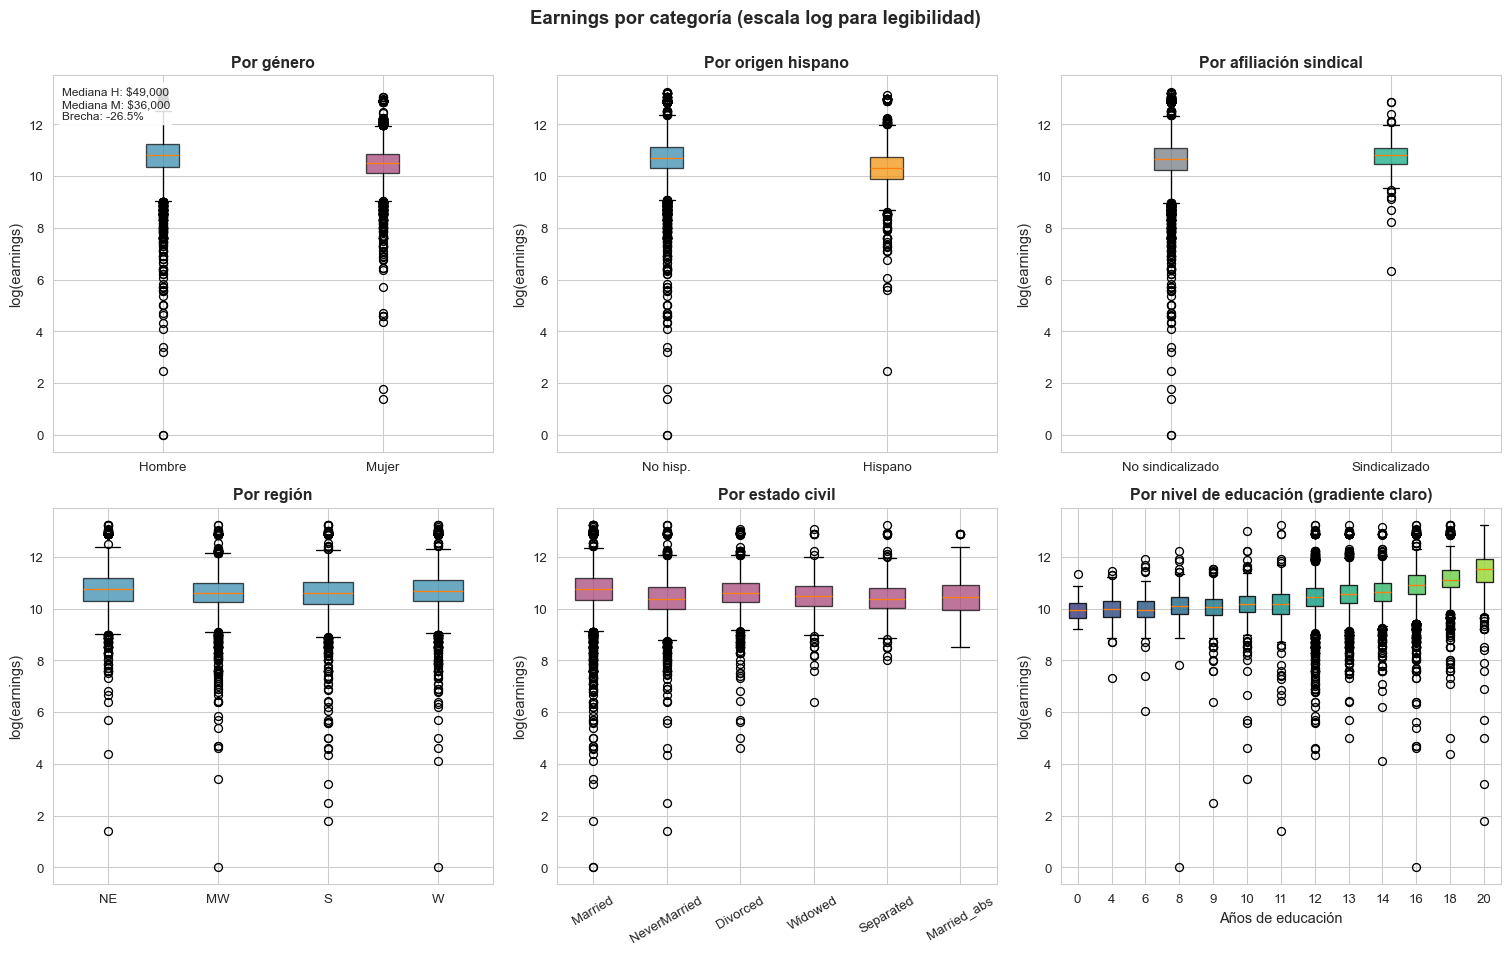

In [36]:
# Mapping para etiquetas legibles
region_map = {1: 'NE', 2: 'MW', 3: 'S', 4: 'W'}
marital_map = {1:'Married', 2:'Married', 3:'Married_abs', 4:'Widowed', 5:'Divorced', 6:'Separated', 7:'NeverMarried'}

df['region_lbl'] = df['region'].map(region_map)
df['marital_lbl'] = df['marital'].map(marital_map)

# Earnings vs variables binarias/categóricas — boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Earnings por categoría (escala log para legibilidad)', fontsize=14, fontweight='bold', y=1.00)

# 1. Género
data_gender = [np.log(df[df['female']==0]['earnings']), np.log(df[df['female']==1]['earnings'])]
bp = axes[0,0].boxplot(data_gender, patch_artist=True, labels=['Hombre','Mujer'])
for patch, color in zip(bp['boxes'], [PALETTE['primary'], PALETTE['secondary']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0,0].set_title('Por género', fontweight='bold')
axes[0,0].set_ylabel('log(earnings)')
m_h = df[df['female']==0]['earnings'].median()
m_m = df[df['female']==1]['earnings'].median()
axes[0,0].text(0.02, 0.97, f'Mediana H: ${m_h:,.0f}\nMediana M: ${m_m:,.0f}\nBrecha: {(m_m/m_h-1)*100:.1f}%',
               transform=axes[0,0].transAxes, va='top', fontsize=9,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# 2. Hispanic
data_hisp = [np.log(df[df['hisp']==0]['earnings']), np.log(df[df['hisp']==1]['earnings'])]
bp = axes[0,1].boxplot(data_hisp, patch_artist=True, labels=['No hisp.','Hispano'])
for patch, color in zip(bp['boxes'], [PALETTE['primary'], PALETTE['warning']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0,1].set_title('Por origen hispano', fontweight='bold')
axes[0,1].set_ylabel('log(earnings)')

# 3. Union
data_union = [np.log(df[df['union']==0]['earnings']), np.log(df[df['union']==1]['earnings'])]
bp = axes[0,2].boxplot(data_union, patch_artist=True, labels=['No sindicalizado','Sindicalizado'])
for patch, color in zip(bp['boxes'], [PALETTE['neutral'], PALETTE['success']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0,2].set_title('Por afiliación sindical', fontweight='bold')
axes[0,2].set_ylabel('log(earnings)')

# 4. Región
regions_order = ['NE','MW','S','W']
data_region = [np.log(df[df['region_lbl']==r]['earnings']) for r in regions_order]
bp = axes[1,0].boxplot(data_region, patch_artist=True, labels=regions_order)
for patch in bp['boxes']:
    patch.set_facecolor(PALETTE['primary']); patch.set_alpha(0.7)
axes[1,0].set_title('Por región', fontweight='bold')
axes[1,0].set_ylabel('log(earnings)')

# 5. Estado civil
marital_order = ['Married', 'NeverMarried', 'Divorced', 'Widowed', 'Separated', 'Married_abs']
marital_avail = [m for m in marital_order if m in df['marital_lbl'].unique()]
data_marital = [np.log(df[df['marital_lbl']==m]['earnings']) for m in marital_avail]
bp = axes[1,1].boxplot(data_marital, patch_artist=True, labels=marital_avail)
for patch in bp['boxes']:
    patch.set_facecolor(PALETTE['secondary']); patch.set_alpha(0.7)
axes[1,1].set_title('Por estado civil', fontweight='bold')
axes[1,1].set_ylabel('log(earnings)')
axes[1,1].tick_params(axis='x', rotation=30)

# 6. Educación (es ordinal pero la tratamos visualmente)
educ_levels = sorted(df['education'].unique())
data_educ = [np.log(df[df['education']==e]['earnings']) for e in educ_levels]
bp = axes[1,2].boxplot(data_educ, patch_artist=True, labels=educ_levels)
# Colorear con gradiente: menos educación más oscuro
n_levels = len(educ_levels)
colors_grad = plt.cm.viridis(np.linspace(0.2, 0.85, n_levels))
for patch, color in zip(bp['boxes'], colors_grad):
    patch.set_facecolor(color); patch.set_alpha(0.85)
axes[1,2].set_title('Por nivel de educación (gradiente claro)', fontweight='bold')
axes[1,2].set_xlabel('Años de educación')
axes[1,2].set_ylabel('log(earnings)')

plt.tight_layout()
plt.show()

**Lo que estos boxplots gritan:**
- **Género:** hay una brecha clara incluso sin controlar por nada más.
- **Hispano:** brecha visible aunque más pequeña.
- **Union:** sindicalizados ganan más en mediana (probablemente correlacionado con industria).
- **Region:** NE y W tienen distribuciones más altas.
- **Marital:** los married ganan más que solteros — el famoso "marriage premium".
- **Educación:** gradiente perfecto. Cada escalón sube. Es nuestro driver más prometedor.


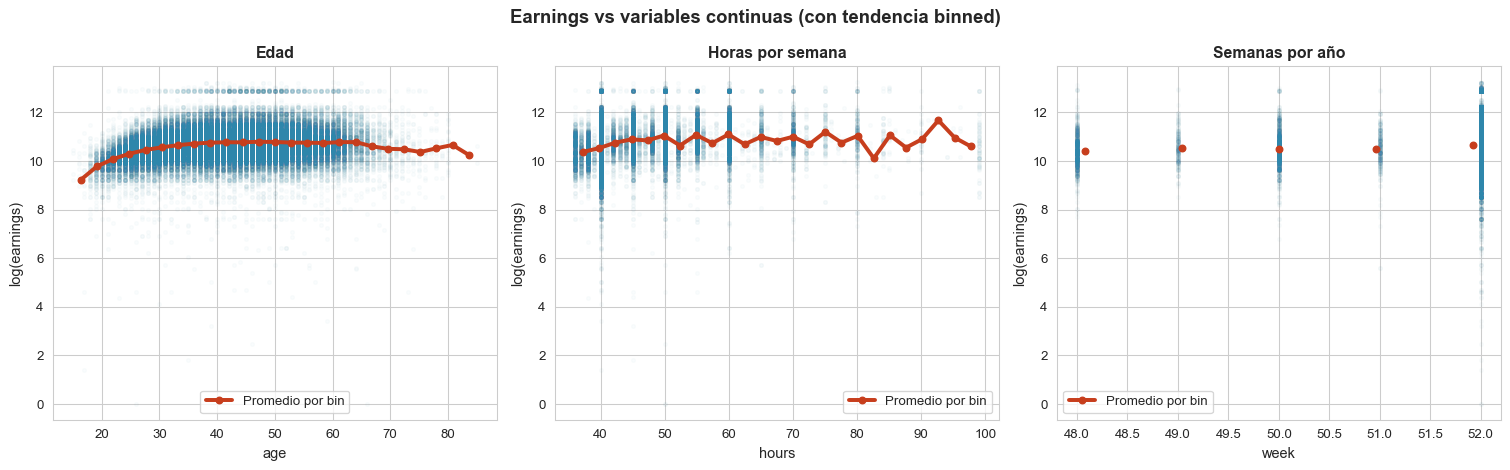

In [37]:
# Relaciones con variables continuas: scatter con regresión local
from scipy.stats import binned_statistic

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Earnings vs variables continuas (con tendencia binned)', fontsize=14, fontweight='bold')

log_earn = np.log(df['earnings'])

for ax, var, title in zip(axes,
                          ['age', 'hours', 'week'],
                          ['Edad', 'Horas por semana', 'Semanas por año']):
    # Scatter alpha bajo (muchos puntos)
    ax.scatter(df[var], log_earn, alpha=0.02, s=8, color=PALETTE['primary'])

    # Tendencia binned (media por bin)
    means, edges, _ = binned_statistic(df[var], log_earn, statistic='mean', bins=25)
    centers = (edges[:-1] + edges[1:]) / 2
    ax.plot(centers, means, color=PALETTE['danger'], linewidth=3, marker='o', markersize=5, label='Promedio por bin')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('log(earnings)')
    ax.legend()

plt.tight_layout()
plt.show()

**Hallazgos críticos:**
- **Edad vs ingreso es cóncava** — sube hasta los 50s y luego se aplana o baja. Esto justifica agregar `age²` como variable para que un modelo lineal pueda capturar esa forma.
- **Horas y semanas** tienen relaciones casi lineales — más trabajo, más ingreso (no sorprende).


### 2.4 Brecha de género desglosada — la pregunta más sensible

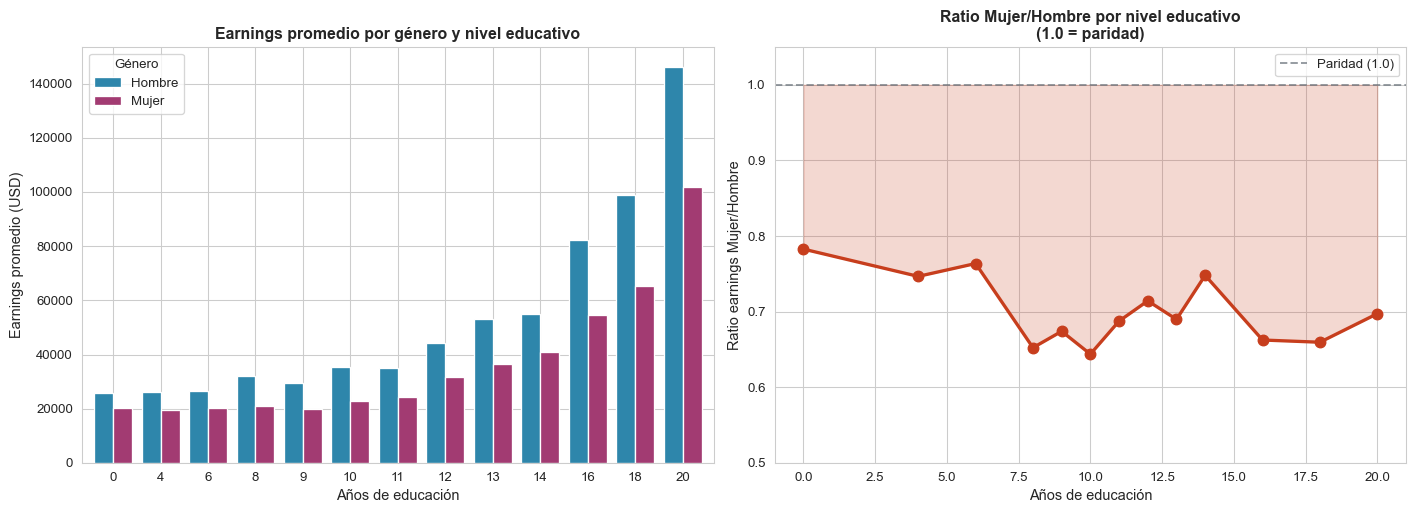

Ratio Mujer/Hombre en niveles clave:
  Educación 12: 0.71 (la mujer gana 71% de lo que gana el hombre)
  Educación 14: 0.75 (la mujer gana 75% de lo que gana el hombre)
  Educación 16: 0.66 (la mujer gana 66% de lo que gana el hombre)
  Educación 18: 0.66 (la mujer gana 66% de lo que gana el hombre)
  Educación 20: 0.70 (la mujer gana 70% de lo que gana el hombre)


In [38]:
# Brecha de género POR nivel de educación — ¿se cierra la brecha con más educación?
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel izquierdo: medias por educación y género
gender_educ = df.groupby(['education','female'])['earnings'].mean().unstack()
gender_educ.columns = ['Hombre', 'Mujer']
gender_educ.plot(kind='bar', ax=axes[0], color=[PALETTE['primary'], PALETTE['secondary']], edgecolor='white', width=0.8)
axes[0].set_title('Earnings promedio por género y nivel educativo', fontweight='bold')
axes[0].set_xlabel('Años de educación')
axes[0].set_ylabel('Earnings promedio (USD)')
axes[0].legend(title='Género')
axes[0].tick_params(axis='x', rotation=0)

# Panel derecho: ratio mujer/hombre por educación
ratio = gender_educ['Mujer'] / gender_educ['Hombre']
axes[1].plot(ratio.index, ratio.values, marker='o', linewidth=2.5, color=PALETTE['danger'], markersize=8)
axes[1].axhline(1.0, color=PALETTE['neutral'], linestyle='--', alpha=0.7, label='Paridad (1.0)')
axes[1].fill_between(ratio.index, ratio.values, 1.0, alpha=0.2, color=PALETTE['danger'])
axes[1].set_title('Ratio Mujer/Hombre por nivel educativo\n(1.0 = paridad)', fontweight='bold')
axes[1].set_xlabel('Años de educación')
axes[1].set_ylabel('Ratio earnings Mujer/Hombre')
axes[1].set_ylim(0.5, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Ratio Mujer/Hombre en niveles clave:")
for ed in [12, 14, 16, 18, 20]:
    if ed in ratio.index:
        print(f"  Educación {ed}: {ratio[ed]:.2f} (la mujer gana {ratio[ed]*100:.0f}% de lo que gana el hombre)")

**Hallazgo poderoso:** la brecha de género **NO se cierra** con más educación. De hecho, en algunos niveles es más grande en niveles educativos altos. Esto es justamente lo que motiva la distinción "inequality vs inequity" de la nota CPS.


### 2.5 Matriz de correlación

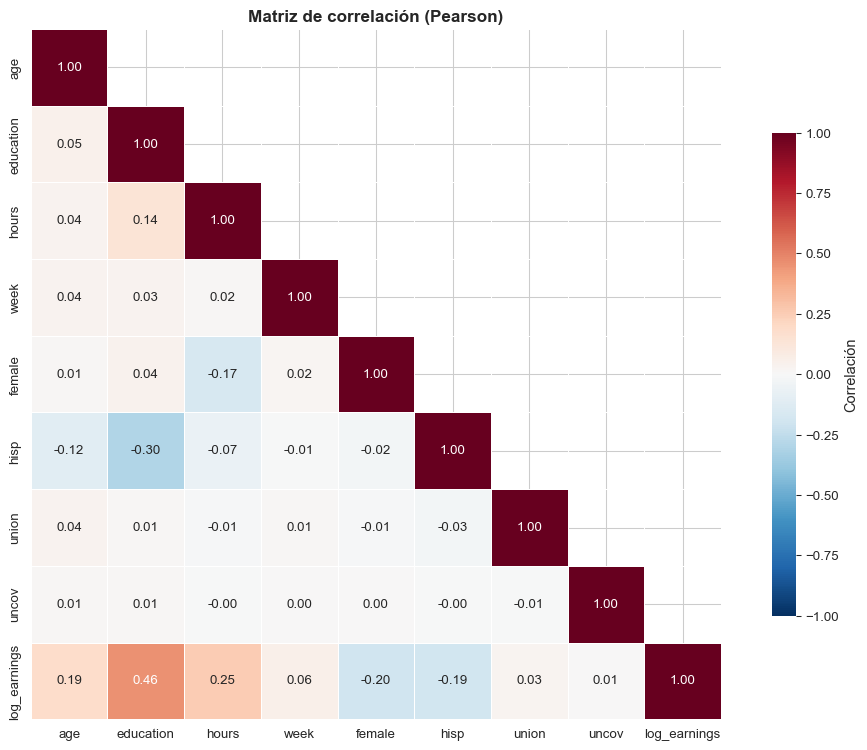


Correlaciones con log(earnings) ordenadas por magnitud:
education    0.456
hours        0.250
female       0.203
hisp         0.188
age          0.187
week         0.059
union        0.025
uncov        0.005
Name: log_earnings, dtype: float64


In [39]:
# Correlaciones entre variables numéricas
fig, ax = plt.subplots(figsize=(11, 8))

corr_vars = ['age','education','hours','week','female','hisp','union','uncov']
corr_with_target = df[corr_vars + ['earnings']].copy()
corr_with_target['log_earnings'] = np.log(corr_with_target['earnings'])
corr_with_target = corr_with_target.drop(columns=['earnings'])

corr = corr_with_target.corr()

# Heatmap con anotaciones
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7, 'label': 'Correlación'}, ax=ax)
ax.set_title('Matriz de correlación (Pearson)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\nCorrelaciones con log(earnings) ordenadas por magnitud:")
print(corr['log_earnings'].drop('log_earnings').abs().sort_values(ascending=False).round(3))

**Lectura:**
- `education` tiene la correlación positiva más fuerte con log(earnings).
- `female` y `hisp` tienen correlación negativa.
- `age`, `hours`, `week` también positivas.
- No hay multicolinealidad alarmante entre predictores (todas las correlaciones inter-predictor < 0.5).


## 3. Limpieza con antes/después visual

Mostramos el efecto de cada paso de limpieza visualmente.


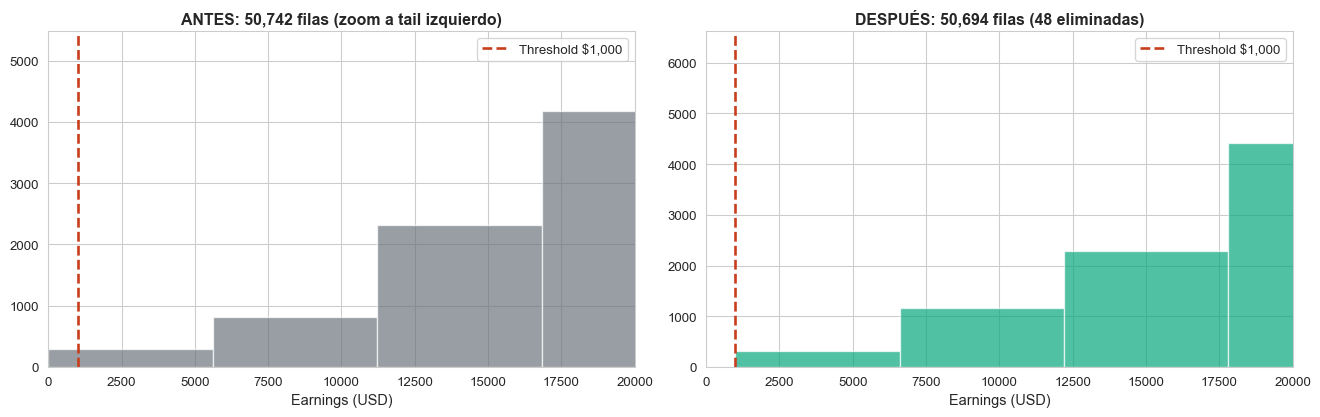

✓ Filtramos 48 filas con earnings < $1,000 (improbables para full-time annual)


In [40]:
# 3.1 Visualizar antes/después de filtrar earnings muy bajos
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Antes
axes[0].hist(df['earnings'], bins=100, color=PALETTE['neutral'], edgecolor='white', alpha=0.7)
axes[0].axvline(1000, color=PALETTE['danger'], linestyle='--', linewidth=2, label='Threshold $1,000')
axes[0].set_xlim(0, 20000)
axes[0].set_title(f'ANTES: {len(df):,} filas (zoom a tail izquierdo)', fontweight='bold')
axes[0].set_xlabel('Earnings (USD)')
axes[0].legend()

# Filtrar
filtered_low = (df['earnings'] < 1000).sum()
df = df[df['earnings'] >= 1000].copy()

# Después
axes[1].hist(df['earnings'], bins=100, color=PALETTE['success'], edgecolor='white', alpha=0.7)
axes[1].axvline(1000, color=PALETTE['danger'], linestyle='--', linewidth=2, label='Threshold $1,000')
axes[1].set_xlim(0, 20000)
axes[1].set_title(f'DESPUÉS: {len(df):,} filas ({filtered_low} eliminadas)', fontweight='bold')
axes[1].set_xlabel('Earnings (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"✓ Filtramos {filtered_low} filas con earnings < $1,000 (improbables para full-time annual)")

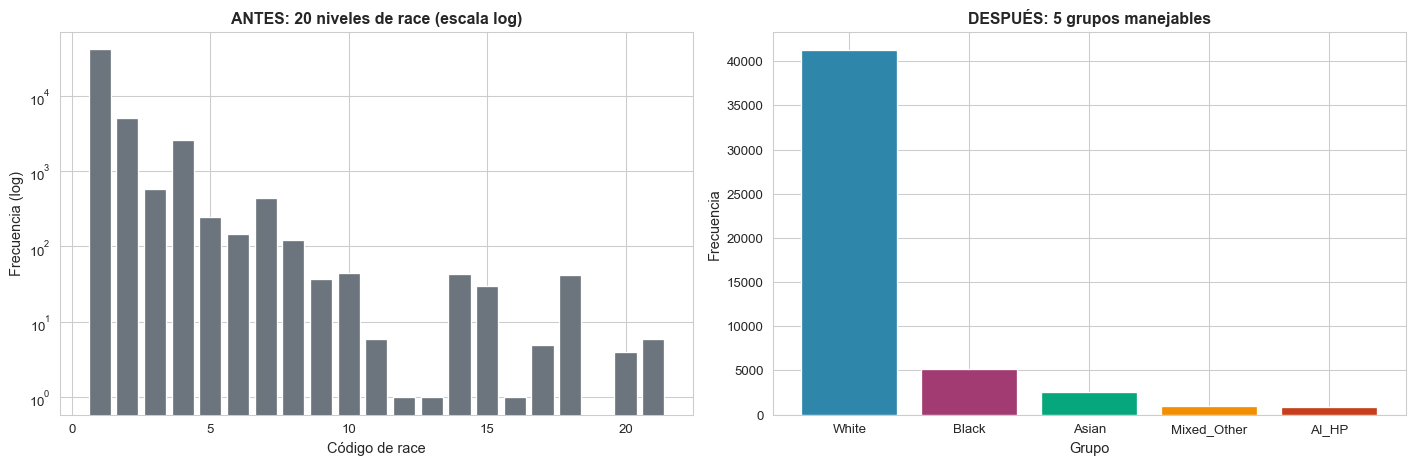

Distribución final de race_group:
race_group
White          41243
Black           5125
Asian           2582
Mixed_Other      924
AI_HP            820


In [41]:
# 3.2 Agrupar race — visualizar antes/después
def race_group(r):
    if r == 1: return 'White'
    elif r == 2: return 'Black'
    elif r == 4: return 'Asian'
    elif r in [3, 5]: return 'AI_HP'
    else: return 'Mixed_Other'

df['race_group'] = df['race'].apply(race_group)
df['log_earnings'] = np.log(df['earnings'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Antes: 21 niveles
race_counts_before = df['race'].value_counts().sort_index()
axes[0].bar(race_counts_before.index, race_counts_before.values, color=PALETTE['neutral'], edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title(f'ANTES: {df["race"].nunique()} niveles de race (escala log)', fontweight='bold')
axes[0].set_xlabel('Código de race')
axes[0].set_ylabel('Frecuencia (log)')

# Después: 5 grupos
race_counts_after = df['race_group'].value_counts()
colors_after = [PALETTE['primary'], PALETTE['secondary'], PALETTE['success'], PALETTE['warning'], PALETTE['danger']]
axes[1].bar(race_counts_after.index, race_counts_after.values, color=colors_after[:len(race_counts_after)], edgecolor='white')
axes[1].set_title(f'DESPUÉS: {df["race_group"].nunique()} grupos manejables', fontweight='bold')
axes[1].set_xlabel('Grupo')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("Distribución final de race_group:")
print(df['race_group'].value_counts().to_string())

## 4. Feature engineering visualizado

### 4.1 ¿Por qué `age²`?

La relación edad-ingreso es cóncava (lo vimos en la sección 2.3). Un modelo lineal puro solo puede ajustar una línea recta — necesita ayuda para capturar la curvatura.


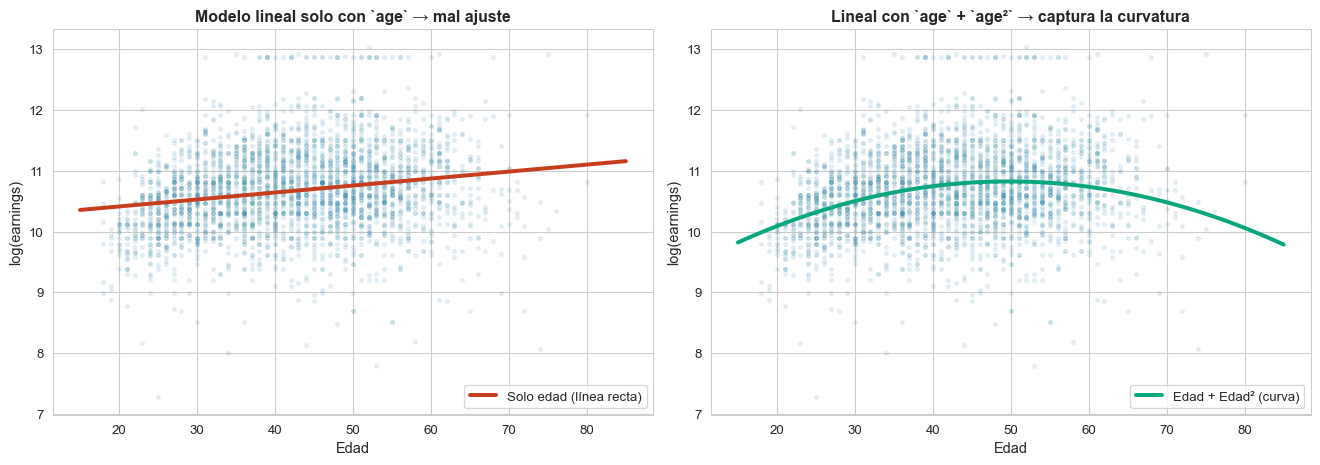

R² con solo age:          0.0377
R² con age + age² (cuadr): 0.0725
→ El término cuadrático mejora claramente el ajuste.


In [42]:
# Demostrar visualmente por qué age² ayuda
from numpy.polynomial import polynomial as P

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ajuste lineal vs polinomial en edad
x = df['age'].values
y = df['log_earnings'].values

# Sample para que el scatter sea visible
idx_sample = np.random.RandomState(42).choice(len(df), 3000, replace=False)
x_s, y_s = x[idx_sample], y[idx_sample]

# Modelo solo con age
coef_lin = np.polyfit(x, y, 1)
x_grid = np.linspace(x.min(), x.max(), 100)
y_lin = np.polyval(coef_lin, x_grid)

# Modelo con age + age²
coef_quad = np.polyfit(x, y, 2)
y_quad = np.polyval(coef_quad, x_grid)

axes[0].scatter(x_s, y_s, alpha=0.1, s=8, color=PALETTE['primary'])
axes[0].plot(x_grid, y_lin, color=PALETTE['danger'], linewidth=3, label='Solo edad (línea recta)')
axes[0].set_title('Modelo lineal solo con `age` → mal ajuste', fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('log(earnings)')
axes[0].legend()

axes[1].scatter(x_s, y_s, alpha=0.1, s=8, color=PALETTE['primary'])
axes[1].plot(x_grid, y_quad, color=PALETTE['success'], linewidth=3, label='Edad + Edad² (curva)')
axes[1].set_title('Lineal con `age` + `age²` → captura la curvatura', fontweight='bold')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('log(earnings)')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"R² con solo age:          {np.corrcoef(x, y)[0,1]**2:.4f}")
print(f"R² con age + age² (cuadr): {(np.corrcoef(np.polyval(coef_quad, x), y)[0,1]**2):.4f}")
print("→ El término cuadrático mejora claramente el ajuste.")

In [43]:
# Feature engineering completo
df['age_sq'] = df['age'] ** 2

numeric_features = ['age', 'age_sq', 'education', 'hours', 'week']
binary_features  = ['female', 'hisp', 'union', 'uncov']
categorical_features = ['region_lbl', 'marital_lbl', 'race_group']

df_model = pd.get_dummies(
    df[numeric_features + binary_features + categorical_features + ['log_earnings']],
    columns=categorical_features,
    drop_first=True,
    dtype=float
)

print(f"✓ Dataset modelable: {df_model.shape[0]:,} filas × {df_model.shape[1]} columnas")
print(f"  Variables predictoras: {df_model.shape[1]-1}")
print(f"  Predictoras: {[c for c in df_model.columns if c != 'log_earnings']}")

✓ Dataset modelable: 50,694 filas × 22 columnas
  Variables predictoras: 21
  Predictoras: ['age', 'age_sq', 'education', 'hours', 'week', 'female', 'hisp', 'union', 'uncov', 'region_lbl_NE', 'region_lbl_S', 'region_lbl_W', 'marital_lbl_Married', 'marital_lbl_Married_abs', 'marital_lbl_NeverMarried', 'marital_lbl_Separated', 'marital_lbl_Widowed', 'race_group_Asian', 'race_group_Black', 'race_group_Mixed_Other', 'race_group_White']


### Preparación para modelar: validación cruzada en lugar de holdout

En vez de partir los datos **una sola vez** en *train/test*, evaluaremos cada modelo con **validación cruzada de 5 folds** (5-fold CV):

- Los datos se reparten en 5 bloques. Cada modelo se entrena 5 veces: en cada vuelta un bloque distinto sirve de validación y los otros 4 de entrenamiento.
- La métrica reportada es el **promedio de los 5 folds** ± la **desviación entre folds**. Es un estimado más estable y menos sensible al azar de una partición única.
- Los **modelos finales que vamos a interpretar** (coeficientes OLS/Lasso, feature importance, PDP, SHAP) se ajustan sobre **todos los datos**: para *explicar* conviene usar toda la información disponible.

> 📌 La validación cruzada responde *"¿qué tan bien generaliza?"*; el ajuste sobre el set completo da los *coeficientes e importancias* más precisos para *interpretar*.

In [ ]:
# Preparación para modelar — SIN holdout train/test: usaremos validación cruzada
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

y = df_model['log_earnings']
X = df_model.drop(columns=['log_earnings'])

# Estandarización del set COMPLETO (la usan Lasso y los gráficos de coeficientes)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# CV EXTERNA: 5 folds barajados — mide el desempeño final de cada modelo
N_SPLITS = 5
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# CV INTERNA: 3 folds — se usa SOLO para el tuning de hiperparámetros.
# Anidar ambas (ver sección 5.0) evita el sesgo de tunear y evaluar con los mismos datos.
INNER_SPLITS = 3
inner_cv = KFold(n_splits=INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE + 1)

# Visualizar el esquema de 5-fold CV (la validación externa)
fig, ax = plt.subplots(figsize=(11, 3.4))
for fold in range(N_SPLITS):
    for block in range(N_SPLITS):
        es_val = (block == fold)
        ax.barh(fold, 1, left=block, height=0.72,
                color=PALETTE['warning'] if es_val else PALETTE['primary'],
                edgecolor='white')
    ax.text(N_SPLITS + 0.15, fold, f'Iteración {fold + 1}', va='center', fontweight='bold')
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, N_SPLITS + 1.6)
ax.invert_yaxis()
ax.set_title(f'Validación cruzada {N_SPLITS}-fold sobre {len(X):,} observaciones\n'
             'Naranja = bloque de validación   |   Azul = bloques de entrenamiento',
             fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✓ X: {X.shape[0]:,} filas × {X.shape[1]} columnas predictoras")
print(f"✓ CV externa (evaluación): {N_SPLITS} folds  |  CV interna (tuning): {INNER_SPLITS} folds")
print(f"  Cada fold externo valida sobre ~{len(X)//N_SPLITS:,} obs. y entrena con ~{len(X)-len(X)//N_SPLITS:,}.")

## 5. Modelaje (5 modelos con diagnóstico visual)

Vamos a entrenar cinco modelos. Después de cada uno, generamos su diagnóstico visual propio.


### 5.0 Tuning de hiperparámetros — sin fugas ni sobreajuste

Antes de entrenar los modelos finales **buscamos sus mejores hiperparámetros** (la "configuración" de cada algoritmo: profundidad del árbol, variables por split, learning rate, etc.). Lo hacemos siguiendo tres reglas para no engañarnos a nosotros mismos:

**1. Sin fuga de datos (data leakage).** Todo preprocesamiento que "aprende" de los datos (la estandarización que usa Lasso) va dentro de un `Pipeline`. Así el `StandardScaler` se ajusta **solo con los datos de entrenamiento** de cada fold, nunca con los de validación.

**2. La búsqueda se evalúa con validación cruzada.** Con `GridSearchCV` / `RandomizedSearchCV` cada combinación de hiperparámetros se puntúa en folds que no participaron en su ajuste. Elegimos la que mejor **generaliza**, no la que mejor memoriza. Además acotamos los rangos hacia la regularización (profundidad limitada, hojas con muchos datos) para no invitar al sobreajuste.

**3. Evaluación honesta con validación cruzada ANIDADA (nested CV).** Aquí está la sutileza clave: *elegir la mejor de muchas combinaciones es, en sí mismo, una forma de sobreajuste* — la "mejor" tiene algo de suerte. Si reportáramos su score de búsqueda estaríamos siendo optimistas. La solución es **anidar dos validaciones cruzadas**:

| | Rol | Cómo funciona |
|---|---|---|
| **Loop externo** (`cv`, 5 folds) | Mide el desempeño | Cada fold externo se reserva *solo para evaluar* |
| **Loop interno** (`inner_cv`, 3 folds) | Elige los hiperparámetros | Corre *dentro* del train de cada fold externo |

Como el tuning de cada fold externo nunca ve su fold de validación, el R² resultante es un estimado **insesgado** del desempeño real. Eso es lo que compararemos en la sección 6.

> 📌 **OLS** no tiene hiperparámetros que tunear. **Lasso** ya se tunea solo: `LassoCV` elige `alpha` por validación cruzada — es tuning hecho correctamente. Tuneamos por tanto **árbol, Random Forest y Gradient Boosting**.
>
> ⏱️ La validación cruzada anidada entrena cientos de modelos: **la sección 6 puede tardar varios minutos** al correrla.


### 5.1 OLS — el modelo interpretable por excelencia

In [ ]:
import statsmodels.api as sm

# Modelo final OLS: ajustado sobre TODOS los datos para interpretar coeficientes y p-values
X_ols = sm.add_constant(X)
ols_model = sm.OLS(y, X_ols).fit()
print(ols_model.summary())

**Cómo leer la tabla (recordando la nota IPADE):**
1. **Signo del coeficiente** → dirección.
2. **Magnitud (|coef|)** → tamaño del efecto (en log = ~% de cambio).
3. **p-value (`P>|t|`)** → confiabilidad. <0.05 significativo.


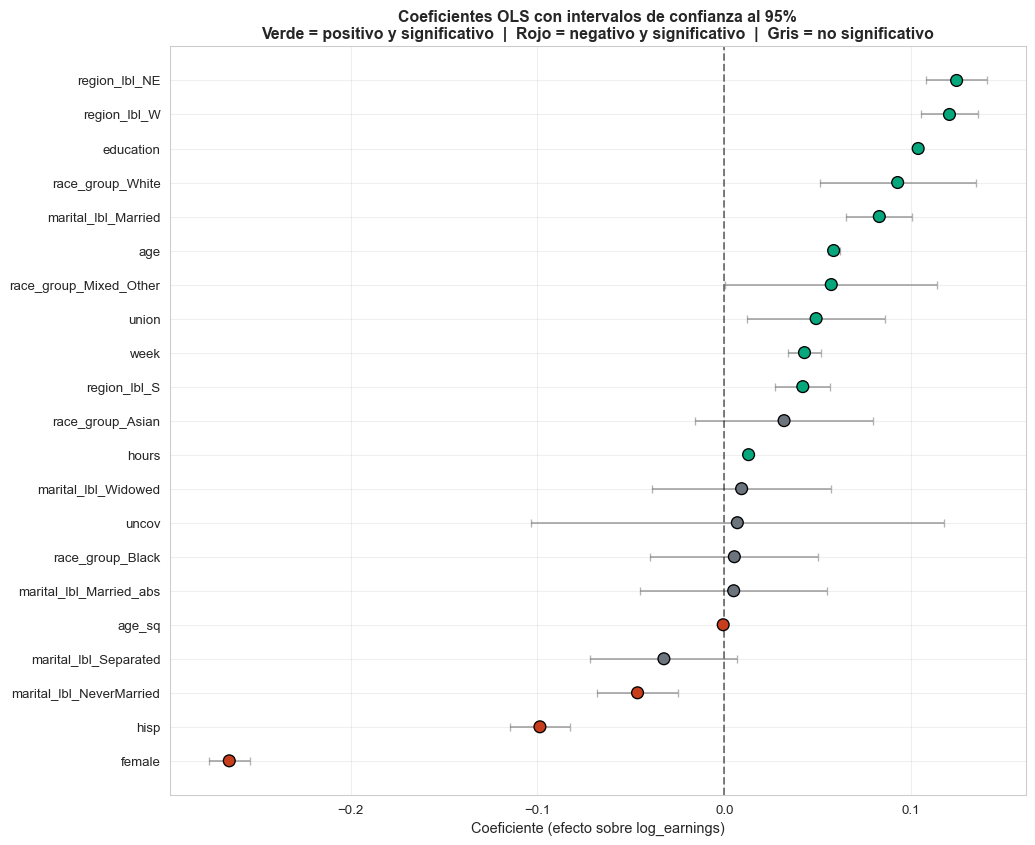

In [46]:
# Visualización de coeficientes OLS — forest plot con intervalos de confianza
coefs_df = pd.DataFrame({
    'coef': ols_model.params,
    'ci_lower': ols_model.conf_int()[0],
    'ci_upper': ols_model.conf_int()[1],
    'p_value': ols_model.pvalues
}).drop('const', errors='ignore')

coefs_df['signif'] = coefs_df['p_value'] < 0.05
coefs_df['pct_effect'] = (np.exp(coefs_df['coef']) - 1) * 100
coefs_df = coefs_df.sort_values('coef')

fig, ax = plt.subplots(figsize=(11, 9))
colors = [PALETTE['success'] if (c > 0 and s) else PALETTE['danger'] if (c < 0 and s) else PALETTE['neutral']
          for c, s in zip(coefs_df['coef'], coefs_df['signif'])]

y_pos = np.arange(len(coefs_df))
ax.errorbar(coefs_df['coef'], y_pos,
            xerr=[coefs_df['coef'] - coefs_df['ci_lower'], coefs_df['ci_upper'] - coefs_df['coef']],
            fmt='none', ecolor='gray', capsize=3, alpha=0.6)
ax.scatter(coefs_df['coef'], y_pos, c=colors, s=80, edgecolor='black', zorder=3)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(coefs_df.index)
ax.set_xlabel('Coeficiente (efecto sobre log_earnings)')
ax.set_title('Coeficientes OLS con intervalos de confianza al 95%\n'
             'Verde = positivo y significativo  |  Rojo = negativo y significativo  |  Gris = no significativo',
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
# Tabla ordenada por efecto + significancia
coefs_table = coefs_df.copy()
coefs_table['signif_label'] = coefs_table['p_value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '.' if p < 0.10 else ''
)
coefs_table[['coef','pct_effect','p_value','signif_label']].sort_values('coef', key=abs, ascending=False).round(4)

,coef,pct_effect,p_value,signif_label
female,-0.2649,-23.2738,0.0000,***
region_lbl_NE,0.1243,13.2396,0.0000,***
region_lbl_W,0.1205,12.8072,0.0000,***
education,0.1038,10.9345,0.0000,***
hisp,-0.0987,-9.3959,0.0000,***
race_group_White,0.0928,9.7224,0.0000,***
marital_lbl_Married,0.0830,8.6511,0.0000,***
age,0.0585,6.0275,0.0000,***
race_group_Mixed_Other,0.0573,5.8930,0.0482,*
union,0.0491,5.0375,0.0094,**


**Interpretación clave del forest plot:**
- Las variables más a la derecha (efecto positivo grande) y a la izquierda (efecto negativo grande) son los drivers principales.
- Las barras de error que cruzan el cero indican variables NO significativas (gris).
- En log, un coeficiente de 0.10 ≈ +10% de earnings; -0.20 ≈ -18% de earnings.


### 5.2 Lasso — selección automática de variables

Para visualizar Lasso, vamos a ver el "camino" de los coeficientes mientras se va aumentando la penalización.


In [ ]:
from sklearn.linear_model import Lasso, LassoCV

# Lasso path: cómo se mueven los coeficientes según alpha (sobre el set completo estandarizado)
alphas = np.logspace(-4, 0, 50)
coefs_path = []
for alpha in alphas:
    l = Lasso(alpha=alpha, max_iter=5000, random_state=RANDOM_STATE)
    l.fit(X_scaled, y)
    coefs_path.append(l.coef_)
coefs_path = np.array(coefs_path)

# LassoCV YA ES tuning de hiperparámetros: elige alpha (la penalización) por
# validación cruzada. Es el "search" del Lasso, hecho correctamente con CV.
lasso = LassoCV(cv=inner_cv, random_state=RANDOM_STATE, n_jobs=-1, max_iter=5000)
lasso.fit(X_scaled, y)
best_alpha = lasso.alpha_

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel 1: el path de Lasso
top_features_idx = np.argsort(np.abs(lasso.coef_))[::-1][:8]
for i in top_features_idx:
    axes[0].plot(alphas, coefs_path[:, i], linewidth=2, label=X_scaled.columns[i])
axes[0].axvline(best_alpha, color=PALETTE['danger'], linestyle='--', linewidth=2,
                label=f'α óptimo = {best_alpha:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('α (penalización)')
axes[0].set_ylabel('Valor del coeficiente')
axes[0].set_title('Lasso path: cómo desaparecen los coeficientes\nal aumentar penalización (top 8)',
                  fontweight='bold')
axes[0].legend(loc='best', fontsize=9, ncol=2)
axes[0].grid(True, alpha=0.3)

# Panel 2: número de variables activas vs alpha
n_active = (coefs_path != 0).sum(axis=1)
axes[1].plot(alphas, n_active, linewidth=3, color=PALETTE['primary'], marker='o', markersize=4)
axes[1].axvline(best_alpha, color=PALETTE['danger'], linestyle='--', linewidth=2,
                label=f'α óptimo = {best_alpha:.4f}\n→ {(lasso.coef_ != 0).sum()} variables activas')
axes[1].set_xscale('log')
axes[1].set_xlabel('α (penalización)')
axes[1].set_ylabel('Número de variables con coef ≠ 0')
axes[1].set_title('Variables activas vs penalización', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"α óptimo (elegido por validación cruzada): {best_alpha:.5f}")
print(f"Variables activas: {(lasso.coef_ != 0).sum()} de {len(lasso.coef_)}")

In [ ]:
# Coeficientes Lasso ordenados visualmente
lasso_coefs = pd.DataFrame({
    'feature': X_scaled.columns,
    'coef': lasso.coef_
}).sort_values('coef')

fig, ax = plt.subplots(figsize=(11, 8))
colors = [PALETTE['success'] if c > 0 else PALETTE['danger'] if c < 0 else PALETTE['neutral']
          for c in lasso_coefs['coef']]
ax.barh(lasso_coefs['feature'], lasso_coefs['coef'], color=colors, edgecolor='black', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente Lasso (escala estandarizada)')
ax.set_title('Drivers según Lasso\nVerde = empuja ingreso arriba | Rojo = empuja abajo | Gris = eliminado',
             fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### 5.3 Árbol de decisión — reglas if-then visualizables

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Espacio de búsqueda — rangos que FAVORECEN la regularización (anti-sobreajuste):
#   max_depth acotado y min_samples_leaf alto = hojas con suficientes datos.
tree_grid = {
    'max_depth':        [3, 4, 5, 6, 8],
    'min_samples_leaf': [50, 100, 200, 400],
}

# GridSearchCV prueba TODAS las combinaciones; cada una se puntúa con la CV interna,
# es decir en folds que no participaron en su ajuste → sin fuga de datos.
tree_search = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    tree_grid, cv=inner_cv, scoring='r2', n_jobs=-1
)
tree_search.fit(X, y)
tree = tree_search.best_estimator_   # mejor árbol, ya reajustado sobre todos los datos

# Visualizar el paisaje de la búsqueda: R² (CV interna) por combinación
tree_scores = (pd.DataFrame(tree_search.cv_results_)
               .pivot(index='param_min_samples_leaf', columns='param_max_depth',
                      values='mean_test_score')
               .sort_index().sort_index(axis=1))
fig, ax = plt.subplots(figsize=(8, 4.6))
sns.heatmap(tree_scores, annot=True, fmt='.4f', cmap='viridis',
            cbar_kws={'label': 'R² (CV interna)'}, ax=ax)
best_r, best_c = np.unravel_index(np.nanargmax(tree_scores.values), tree_scores.shape)
ax.scatter([best_c + 0.5], [best_r + 0.5], marker='*', s=450,
           color=PALETTE['danger'], edgecolor='white', zorder=5, label='Mejor combinación')
ax.set_title('Tuning del árbol: R² (CV interna) por combinación de hiperparámetros',
             fontweight='bold')
ax.set_xlabel('max_depth')
ax.set_ylabel('min_samples_leaf')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Mejores hiperparámetros: {tree_search.best_params_}")
print(f"R² CV interna (de la búsqueda): {tree_search.best_score_:.4f}")
print(f"R² in-sample (todos los datos): {tree.score(X, y):.4f}")
print("→ La evaluación HONESTA (validación cruzada anidada) está en la sección 6.")

In [ ]:
# El árbol grande, completo
fig, ax = plt.subplots(figsize=(24, 11))
plot_tree(tree, feature_names=X.columns, filled=True, rounded=True,
          fontsize=9, max_depth=3, impurity=False, precision=2, ax=ax)
plt.title('Árbol de decisión (primeros 3 niveles)\nValor en cada hoja = log(earnings) promedio del grupo',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance del árbol
tree_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': tree.feature_importances_
}).sort_values('importance', ascending=True)
tree_imp = tree_imp[tree_imp['importance'] > 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(tree_imp['feature'], tree_imp['importance'], color=PALETTE['primary'], edgecolor='white')
ax.set_xlabel('Importancia (reducción de varianza)')
ax.set_title('Variables usadas por el árbol (las que NO aparecen, no se usaron)', fontweight='bold')
plt.tight_layout()
plt.show()

**Lectura:** el árbol (con la profundidad elegida por el tuning) solo usa unas pocas variables. Las que NO aparecen no son inútiles — es que el árbol "se las saltó" porque las primeras splits ya capturaron suficiente varianza. Por eso necesitamos Random Forest para una vista más completa.


### 5.4 Random Forest — captura no-linealidades e interacciones

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Espacio de búsqueda. n_estimators se FIJA alto (300): más árboles solo estabiliza,
# no sobreajusta. Tuneamos lo que SÍ controla la complejidad de cada árbol.
rf_dist = {
    'max_depth':        [8, 12, 16, 20],
    'min_samples_leaf': [5, 10, 20, 40],
    'max_features':     [0.3, 0.5, 0.7, 1.0],
}

# RandomizedSearchCV muestrea 10 combinaciones al azar (más eficiente que probar las 64).
# Cada una se evalúa con la CV interna → sin fuga de datos.
rf_search = RandomizedSearchCV(
    RandomForestRegressor(n_estimators=300, oob_score=True, n_jobs=-1, random_state=RANDOM_STATE),
    rf_dist, n_iter=10, cv=inner_cv, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X, y)
rf = rf_search.best_estimator_   # mejor bosque, ya reajustado sobre todos los datos

# Visualizar las combinaciones probadas, ordenadas por R² CV
rf_res = pd.DataFrame(rf_search.cv_results_).sort_values('mean_test_score')
labels = [f"depth={p['max_depth']}, leaf={p['min_samples_leaf']}, feat={p['max_features']}"
          for p in rf_res['params']]
fig, ax = plt.subplots(figsize=(11, 5))
colors = [PALETTE['success'] if s == rf_res['mean_test_score'].max() else PALETTE['primary']
          for s in rf_res['mean_test_score']]
ax.barh(range(len(rf_res)), rf_res['mean_test_score'], xerr=rf_res['std_test_score'],
        capsize=3, color=colors, edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(rf_res)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('R² (CV interna)')
ax.set_title('Tuning del Random Forest: las 10 combinaciones probadas\n(verde = ganadora)',
             fontweight='bold')
ax.set_xlim(rf_res['mean_test_score'].min() - 0.01, rf_res['mean_test_score'].max() + 0.008)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"Mejores hiperparámetros: {rf_search.best_params_}")
print(f"R² CV interna (de la búsqueda): {rf_search.best_score_:.4f}")
print(f"R² in-sample (todos los datos): {rf.score(X, y):.4f}")
print(f"R² OOB (out-of-bag):            {rf.oob_score_:.4f}")
print("→ La evaluación HONESTA (validación cruzada anidada) está en la sección 6.")

In [ ]:
# Curva de aprendizaje del Random Forest usando el error OOB (out-of-bag).
# El OOB es "validación cruzada incorporada": cada árbol se evalúa con las
# observaciones que no le tocaron en su muestra bootstrap.
# Usamos los hiperparámetros YA TUNEADOS (rf_search.best_params_).
from sklearn.metrics import mean_squared_error

n_trees_range = [10, 25, 50, 100, 150, 200, 250, 300]
train_errors = []
oob_errors = []

y_arr = y.values
for n in n_trees_range:
    rf_temp = RandomForestRegressor(n_estimators=n, **rf_search.best_params_,
                                    oob_score=True, n_jobs=-1, random_state=RANDOM_STATE)
    rf_temp.fit(X, y)
    train_errors.append(np.sqrt(mean_squared_error(y_arr, rf_temp.predict(X))))
    oob_pred = rf_temp.oob_prediction_
    mask = ~np.isnan(oob_pred)   # con pocos árboles algunas obs. no tienen predicción OOB
    oob_errors.append(np.sqrt(mean_squared_error(y_arr[mask], oob_pred[mask])))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(n_trees_range, train_errors, marker='o', linewidth=2.5,
        label='Train RMSE (in-sample)', color=PALETTE['primary'])
ax.plot(n_trees_range, oob_errors, marker='s', linewidth=2.5,
        label='OOB RMSE (validación incorporada)', color=PALETTE['danger'])
ax.set_xlabel('Número de árboles')
ax.set_ylabel('RMSE')
ax.set_title('Curva de aprendizaje Random Forest (hiperparámetros tuneados):\nel error OOB se estabiliza después de ~100 árboles',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 Gradient Boosting — el benchmark de rendimiento

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Espacio de búsqueda. learning_rate y max_depth controlan la complejidad;
# subsample < 1 introduce aleatoriedad que regulariza (stochastic gradient boosting).
gb_dist = {
    'learning_rate':    [0.03, 0.05, 0.1, 0.15],
    'max_depth':        [2, 3, 4],
    'min_samples_leaf': [20, 50, 100],
    'subsample':        [0.7, 0.85, 1.0],
}

# RandomizedSearchCV muestrea 8 combinaciones, cada una evaluada con la CV interna.
gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(n_estimators=300, random_state=RANDOM_STATE),
    gb_dist, n_iter=8, cv=inner_cv, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1
)
gb_search.fit(X, y)
gb = gb_search.best_estimator_   # mejor modelo, ya reajustado sobre todos los datos

# Visualizar las combinaciones probadas, ordenadas por R² CV
gb_res = pd.DataFrame(gb_search.cv_results_).sort_values('mean_test_score')
labels = [f"lr={p['learning_rate']}, depth={p['max_depth']}, leaf={p['min_samples_leaf']}, sub={p['subsample']}"
          for p in gb_res['params']]
fig, ax = plt.subplots(figsize=(11, 4.6))
colors = [PALETTE['success'] if s == gb_res['mean_test_score'].max() else PALETTE['primary']
          for s in gb_res['mean_test_score']]
ax.barh(range(len(gb_res)), gb_res['mean_test_score'], xerr=gb_res['std_test_score'],
        capsize=3, color=colors, edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(gb_res)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('R² (CV interna)')
ax.set_title('Tuning del Gradient Boosting: las 8 combinaciones probadas\n(verde = ganadora)',
             fontweight='bold')
ax.set_xlim(gb_res['mean_test_score'].min() - 0.01, gb_res['mean_test_score'].max() + 0.008)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"Mejores hiperparámetros: {gb_search.best_params_}")
print(f"R² CV interna (de la búsqueda): {gb_search.best_score_:.4f}")
print(f"R² in-sample (todos los datos): {gb.score(X, y):.4f}")
print("→ La evaluación HONESTA (validación cruzada anidada) está en la sección 6.")

In [ ]:
# Curva de aprendizaje de Gradient Boosting con validación cruzada:
# en cada uno de los 5 folds medimos el RMSE iteración por iteración.
# Usamos los hiperparámetros YA TUNEADOS (gb_search.best_params_).
from sklearn.metrics import mean_squared_error

n_est = gb.n_estimators
cv_staged = np.zeros((N_SPLITS, n_est))
train_staged = np.zeros((N_SPLITS, n_est))

for k, (tr_idx, te_idx) in enumerate(cv.split(X)):
    g = GradientBoostingRegressor(n_estimators=n_est, random_state=RANDOM_STATE,
                                  **gb_search.best_params_)
    g.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    for i, y_pred in enumerate(g.staged_predict(X.iloc[te_idx])):
        cv_staged[k, i] = np.sqrt(mean_squared_error(y.iloc[te_idx], y_pred))
    for i, y_pred in enumerate(g.staged_predict(X.iloc[tr_idx])):
        train_staged[k, i] = np.sqrt(mean_squared_error(y.iloc[tr_idx], y_pred))

stages = np.arange(1, n_est + 1)
cv_mean, cv_std = cv_staged.mean(axis=0), cv_staged.std(axis=0)
train_mean = train_staged.mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(stages, train_mean, linewidth=2.5, label='Train RMSE (promedio 5 folds)', color=PALETTE['primary'])
ax.plot(stages, cv_mean, linewidth=2.5, label='RMSE validación cruzada (promedio 5 folds)', color=PALETTE['danger'])
ax.fill_between(stages, cv_mean - cv_std, cv_mean + cv_std, color=PALETTE['danger'], alpha=0.2,
                label='±1 desviación entre folds')
ax.set_xlabel('Iteración (árbol agregado)')
ax.set_ylabel('RMSE')
ax.set_title('Gradient Boosting tuneado: aprende secuencialmente, cada árbol corrige al anterior\n(curva validada con 5-fold CV)',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Evaluación comparativa visual

Comparamos los 5 modelos desde múltiples ángulos. El desempeño se mide con **validación cruzada anidada** (ver 5.0): cada modelo se tunea y se evalúa de forma que el fold de prueba nunca influyó en sus hiperparámetros — un estimado **honesto**, sin el optimismo del tuning.

> ⏱️ La siguiente celda corre la validación cruzada anidada: entrena cientos de modelos y **puede tardar varios minutos**.


In [ ]:
# Evaluación HONESTA por VALIDACIÓN CRUZADA ANIDADA (nested CV)
#   Loop EXTERNO (cv, 5 folds)        -> mide el desempeño
#   Loop INTERNO (inner_cv, en cada búsqueda) -> elige los hiperparámetros
# Como el tuning de cada fold externo NO ve su fold de validación, el R² resultante
# es un estimado insesgado: no premia el haber tuneado contra esos mismos datos.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cada modelo se representa por su PROCEDIMIENTO completo (con búsqueda incluida).
# El preprocesamiento va dentro de Pipeline -> el scaler se ajusta solo con train.
cv_models = {
    'OLS':   LinearRegression(),
    'Lasso': make_pipeline(StandardScaler(),
                           LassoCV(cv=inner_cv, random_state=RANDOM_STATE, max_iter=5000)),
    'Árbol': GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                          tree_grid, cv=inner_cv, scoring='r2', n_jobs=-1),
    'Random Forest': RandomizedSearchCV(
        RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
        rf_dist, n_iter=10, cv=inner_cv, scoring='r2',
        random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': RandomizedSearchCV(
        GradientBoostingRegressor(n_estimators=300, random_state=RANDOM_STATE),
        gb_dist, n_iter=8, cv=inner_cv, scoring='r2',
        random_state=RANDOM_STATE, n_jobs=-1),
}

print('Corriendo validación cruzada anidada (puede tardar varios minutos)...')
evals = []
for name, model in cv_models.items():
    oof_pred = np.zeros(len(y))                       # predicción out-of-fold de cada obs.
    r2_tr, r2_te, rmse_te, mae_te = [], [], [], []
    for tr_idx, te_idx in cv.split(X):
        m = clone(model)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])         # esto incluye la búsqueda interna
        p_te = m.predict(X.iloc[te_idx])
        p_tr = m.predict(X.iloc[tr_idx])
        oof_pred[te_idx] = p_te
        r2_tr.append(r2_score(y.iloc[tr_idx], p_tr))
        r2_te.append(r2_score(y.iloc[te_idx], p_te))
        rmse_te.append(np.sqrt(mean_squared_error(y.iloc[te_idx], p_te)))
        mae_te.append(mean_absolute_error(y.iloc[te_idx], p_te))
    evals.append({
        'Modelo':      name,
        'R² train':    np.mean(r2_tr),
        'R² CV':       np.mean(r2_te),
        'R² CV std':   np.std(r2_te),
        'RMSE CV':     np.mean(rmse_te),
        'RMSE CV std': np.std(rmse_te),
        'MAE CV':      np.mean(mae_te),
        'pred_cv':     oof_pred,
    })
    print(f"  ✓ {name:18s} R² nested CV = {np.mean(r2_te):.4f} ± {np.std(r2_te):.4f}")

results_df = pd.DataFrame([{k: v for k, v in e.items() if k != 'pred_cv'} for e in evals])
results_df['Error % aprox'] = (np.exp(results_df['MAE CV']) - 1) * 100
results_df.round(4)

In [ ]:
# Comparación visual de las métricas de validación cruzada anidada — un panel grande
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Comparación de los 5 modelos — métricas de validación cruzada anidada',
             fontsize=14, fontweight='bold', y=1.00)

metrics_to_plot = [
    ('R² train', 'R² in-sample (ajuste sobre datos de entrenamiento)',     PALETTE['primary'], True,  None),
    ('R² CV',    'R² nested CV (honesto, sin sesgo de tuning) ⭐ LA QUE IMPORTA', PALETTE['success'], True,  'R² CV std'),
    ('RMSE CV',  'RMSE nested CV (más bajo = mejor)',                       PALETTE['danger'],  False, 'RMSE CV std'),
    ('MAE CV',   'MAE nested CV (más bajo = mejor)',                        PALETTE['warning'], False, None),
]

for ax, (metric, title, color, higher_better, err_col) in zip(axes.flat, metrics_to_plot):
    vals = results_df[metric].values
    errs = results_df[err_col].values if err_col else None
    bars = ax.bar(results_df['Modelo'], vals, yerr=errs, capsize=4,
                  color=color, edgecolor='black', alpha=0.85)

    # Resaltar el mejor
    best_idx = vals.argmax() if higher_better else vals.argmin()
    bars[best_idx].set_color(PALETTE['success'] if higher_better else PALETTE['warning'])
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)

    # Etiquetas con valores
    span = vals.max() - vals.min() if vals.max() != vals.min() else (vals.max() or 1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + span*0.05,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Lectura clave:**
- Los modelos lineales (OLS, Lasso) están cerca de los de árbol → las relaciones son **mayormente lineales**. Esto justifica interpretar coeficientes con confianza.
- Random Forest y Gradient Boosting, **ya tuneados**, tienen R² algo superiores → capturan algo de no-linealidad e interacciones, pero la mejora sobre OLS sigue siendo modesta.
- Estos R² provienen de **validación cruzada anidada**: el estimado honesto, sin el optimismo de haber elegido los hiperparámetros que mejor lucían en CV.
- **R² ~0.33-0.42 es normal** en datos socioeconómicos: gran parte de la varianza en ingresos depende de factores no observados (habilidad, industria específica, suerte).


In [ ]:
# Predicho (out-of-fold) vs real — el plot más informativo de regresión, para los 5 modelos
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))

y_arr = y.values
y_min, y_max = y_arr.min(), y_arr.max()

for ax, ev in zip(axes, evals):
    pred = ev['pred_cv']
    # Hexbin para densidad
    hb = ax.hexbin(y_arr, pred, gridsize=30, cmap='Blues', mincnt=1)
    # Línea perfecta
    ax.plot([y_min, y_max], [y_min, y_max], color=PALETTE['danger'], linestyle='--',
            linewidth=2, label='Predicción perfecta')
    ax.set_xlabel('log(earnings) real')
    ax.set_ylabel('log(earnings) predicho')
    ax.set_title(f"{ev['Modelo']}\nR² nested CV={ev['R² CV']:.3f}", fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Predicho (out-of-fold, validación cruzada anidada) vs Real — ningún punto se predijo con un modelo que ya lo había visto',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Cómo leer esto:** cada modelo se mide contra la línea roja diagonal (predicción perfecta). Las predicciones son **out-of-fold de la validación cruzada anidada**: cada observación se predijo con un modelo entrenado y tuneado sin haberla visto nunca. Si los puntos forman una nube concentrada alrededor de la diagonal → buen ajuste; si están dispersos → mal ajuste. **Los 5 modelos pintan distribuciones similares**, confirmando que las relaciones son mayormente lineales en este problema.

In [ ]:
# Análisis de residuales (out-of-fold) — diagnóstico clave de regresión
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

y_arr = y.values
for col, ev in enumerate(evals):
    residuals = y_arr - ev['pred_cv']

    # Panel arriba: residuales vs predicho
    axes[0, col].scatter(ev['pred_cv'], residuals, alpha=0.15, s=10, color=PALETTE['primary'])
    axes[0, col].axhline(0, color=PALETTE['danger'], linestyle='--', linewidth=2)
    axes[0, col].set_xlabel('Predicho (CV)')
    axes[0, col].set_ylabel('Residual')
    axes[0, col].set_title(f"{ev['Modelo']}: residuales vs predicho", fontweight='bold')

    # Panel abajo: histograma de residuales
    axes[1, col].hist(residuals, bins=50, color=PALETTE['success'], edgecolor='white', alpha=0.85)
    axes[1, col].axvline(0, color=PALETTE['danger'], linestyle='--', linewidth=2)
    axes[1, col].set_xlabel('Residual')
    axes[1, col].set_ylabel('Frecuencia')
    axes[1, col].set_title(f"Distribución residuales\nmedia={residuals.mean():.3f}, std={residuals.std():.3f}",
                            fontweight='bold')

plt.suptitle('Diagnóstico de residuales out-of-fold (deseamos: dispersión aleatoria sin patrón + distribución normal)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Qué buscamos en los residuales:**
- **Arriba (residuales vs predicho):** queremos una nube de puntos sin patrones. Si vemos una forma de embudo o curva, el modelo está mal especificado.
- **Abajo (histograma):** queremos una distribución aproximadamente normal centrada en cero. Eso significa que el modelo no está sesgado sistemáticamente.

En este caso los 5 modelos muestran residuales razonablemente bien comportados, sin patrones alarmantes.


### Side-by-side: ¿qué modelo es el mejor para predecir?

El objetivo del caso es **explicar**, pero conviene saber qué modelo tiene más poder *predictivo*. La siguiente comparación pone los 5 modelos —ya tuneados— lado a lado con sus métricas de **validación cruzada anidada**, los ordena por R² y declara un "campeón" predictivo, sin perder de vista el trade-off con la interpretabilidad.

In [ ]:
# Side-by-side: ranking de modelos por capacidad predictiva (validación cruzada anidada)
from IPython.display import display

ranking = results_df.sort_values('R² CV', ascending=False).reset_index(drop=True)
ranking.insert(0, 'Ranking', ranking.index + 1)
ranking['Brecha train-CV'] = ranking['R² train'] - ranking['R² CV']   # mide sobreajuste

side_by_side = ranking[['Ranking', 'Modelo', 'R² CV', 'R² CV std', 'RMSE CV',
                        'MAE CV', 'R² train', 'Brecha train-CV', 'Error % aprox']]
print('Comparación side-by-side (ordenada por R² de validación cruzada anidada):')
display(side_by_side.round(4))

champion = ranking.iloc[0]

# Score subjetivo de interpretabilidad (para ilustrar el trade-off predicción <-> explicación)
interpretabilidad = {'OLS': 5.0, 'Lasso': 4.5, 'Árbol': 4.0,
                     'Random Forest': 2.0, 'Gradient Boosting': 1.5}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Panel 1: ranking por R² nested CV (mejor arriba) con barras de error
r = ranking.iloc[::-1]
colors = [PALETTE['success'] if m == champion['Modelo'] else PALETTE['primary'] for m in r['Modelo']]
axes[0].barh(r['Modelo'], r['R² CV'], xerr=r['R² CV std'], capsize=4,
             color=colors, edgecolor='black', alpha=0.9)
for i, v in enumerate(r['R² CV']):
    axes[0].text(v + 0.004, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
axes[0].set_xlabel('R² validación cruzada anidada (más alto = mejor predictor)')
axes[0].set_title('Ranking predictivo — R² nested CV\n(verde = campeón predictivo)', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Panel 2: el trade-off predicción vs interpretabilidad
for _, row in ranking.iterrows():
    es_champ = row['Modelo'] == champion['Modelo']
    axes[1].scatter(row['R² CV'], interpretabilidad[row['Modelo']],
                    s=320, color=PALETTE['success'] if es_champ else PALETTE['primary'],
                    edgecolor='black', zorder=3, alpha=0.9)
    axes[1].annotate(row['Modelo'], (row['R² CV'], interpretabilidad[row['Modelo']]),
                     textcoords='offset points', xytext=(0, 14), ha='center',
                     fontsize=9, fontweight='bold')
axes[1].set_xlabel('R² validación cruzada anidada  (poder predictivo →)')
axes[1].set_ylabel('Interpretabilidad  (→ más explicable)')
axes[1].set_title('El trade-off: predecir vs explicar', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, 5.8)

plt.tight_layout()
plt.show()

# Veredicto
mejor_lineal = ranking[ranking['Modelo'].isin(['OLS', 'Lasso'])].iloc[0]
brecha_r2 = champion['R² CV'] - mejor_lineal['R² CV']
print(f"\n🏆 Mejor PREDICTOR (R² nested CV más alto): {champion['Modelo']}  "
      f"-> R² = {champion['R² CV']:.4f} ± {champion['R² CV std']:.4f}")
print(f"   Mejor modelo LINEAL ({mejor_lineal['Modelo']}): R² = {mejor_lineal['R² CV']:.4f}")
print(f"   Diferencia: {brecha_r2:.4f} de R² ({brecha_r2 / champion['R² CV'] * 100:.1f}% relativo).")
print(f"\n   📌 Para ESTE caso buscamos EXPLICAR, no predecir: {mejor_lineal['Modelo']} sacrifica")
print(f"   muy poco R² y a cambio entrega coeficientes con signo, magnitud y p-value.")
print(f"   {champion['Modelo']} gana en predicción pura, pero es una 'caja negra' que")
print(f"   necesita SHAP/PDP para interpretarse.")

## 7. Interpretación visual completa

Aquí aplicamos las tres técnicas que pide la nota IPADE: **Feature Importance + PDP + SHAP** (global y local).


### 7.1 Feature Importance — tres perspectivas comparadas

In [ ]:
# Comparar FI de tree, RF y GB en un solo panel
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

models_fi = [
    ('Árbol de decisión', tree, axes[0]),
    ('Random Forest', rf, axes[1]),
    ('Gradient Boosting', gb, axes[2]),
]

# Conseguir el top 12 de cada uno
for name, model, ax in models_fi:
    fi = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(12)
    fi = fi.sort_values('importance', ascending=True)
    ax.barh(fi['feature'], fi['importance'], color=PALETTE['primary'], edgecolor='white')
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Importancia')

plt.suptitle('Feature Importance: ¿coinciden los modelos en los drivers?',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Observación crítica:** los tres modelos coinciden ampliamente en los top 5 drivers. Cuando varios modelos independientes están de acuerdo, las conclusiones son más sólidas.

**Recordatorio IPADE:** importancia mide contribución a la **precisión predictiva**, no causalidad. Que `education` sea #1 no prueba que educar más cause más ingresos.


### 7.2 Partial Dependence Plots — la forma del efecto

Los PDP muestran cómo cambia la predicción al variar **una sola variable**, dejando el resto constante. Detectan umbrales, rendimientos decrecientes y no-linealidades.


In [ ]:
from sklearn.inspection import PartialDependenceDisplay

continuous_features = ['education', 'age', 'hours', 'week']

fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    rf, X, continuous_features,
    grid_resolution=40, n_cols=2,
    line_kw={'color': PALETTE['primary'], 'linewidth': 2.5},
    ax=ax
)
plt.suptitle('Partial Dependence Plots (Random Forest)\nCómo varía la predicción al mover cada variable',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
# PDP de variables binarias (categorías) — más fácil leer como barras
binary_to_plot = ['female', 'union', 'hisp']
for col in X.columns:
    if col.startswith('marital_lbl_') and 'Married' in col:
        binary_to_plot.append(col); break

fig, axes = plt.subplots(1, len(binary_to_plot), figsize=(15, 4.5))

for ax, var in zip(axes, binary_to_plot):
    # PDP manual para binarias
    X_temp = X.copy()
    X_temp[var] = 0
    pred_0 = rf.predict(X_temp).mean()
    X_temp[var] = 1
    pred_1 = rf.predict(X_temp).mean()
    diff = pred_1 - pred_0

    bars = ax.bar(['0', '1'], [pred_0, pred_1],
                   color=[PALETTE['neutral'], PALETTE['primary']], edgecolor='black', alpha=0.85)
    ax.set_title(f'{var}\nΔ = {diff:+.3f} log = {(np.exp(diff)-1)*100:+.1f}%',
                 fontweight='bold')
    ax.set_ylabel('Predicción promedio log(earnings)')
    ax.set_ylim(pred_0 - abs(diff)*1.5, pred_1 + abs(diff)*1.5)

    for bar, val in zip(bars, [pred_0, pred_1]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Efecto de variables binarias sobre la predicción',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Lectura de los PDP:**
- **Educación:** pendiente fuerte y creciente — cada año educativo agrega ingreso. El "premium" se acelera después de 14-16 años.
- **Edad:** curva cóncava — sube hasta los 45-55 años, después se aplana.
- **Horas y semanas:** relaciones casi lineales.
- **Female:** efecto negativo claro y cuantificable (en términos %).
- **Union:** efecto positivo moderado.


### 7.3 SHAP — explicaciones globales Y locales

SHAP es lo más avanzado en explicabilidad. Cada predicción se descompone en contribuciones por variable.


In [ ]:
try:
    import shap
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

# Muestra para que SHAP corra rápido
sample_size = 1000
X_sample = X.sample(sample_size, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# Manejar expected_value
expected_val = explainer.expected_value
if hasattr(expected_val, '__len__'):
    expected_val = float(np.array(expected_val).flatten()[0])

print(f"✓ SHAP calculado para {sample_size} casos")
print(f"  Valor base (expected_value): {expected_val:.3f}")

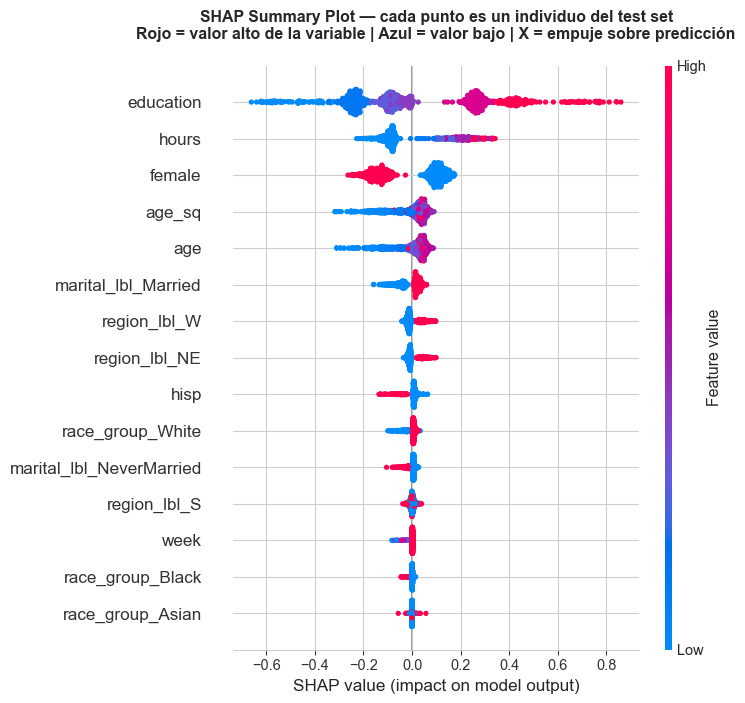

In [65]:
# 7.3.a SHAP summary plot — vista global con dirección de efecto
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title('SHAP Summary Plot — cada punto es un individuo del test set\n'
          'Rojo = valor alto de la variable | Azul = valor bajo | X = empuje sobre predicción',
          fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Cómo leer el SHAP summary (¡el plot más informativo del notebook!):**
- Cada **punto es una observación**.
- **Eje Y:** variables ordenadas por importancia.
- **Eje X:** cuánto empuja esa variable la predicción individual (derecha = sube ingreso; izquierda = baja).
- **Color:** rojo = valor alto de la variable; azul = valor bajo.

**Patrones a buscar:**
- `education` rojo a la derecha + azul a la izquierda → relación monótona positiva (educación alta = ingreso alto).
- `female=1` (rojo) a la izquierda → ser mujer empuja la predicción hacia abajo.
- `hours` y `week` rojo a la derecha → trabajar más empuja arriba.


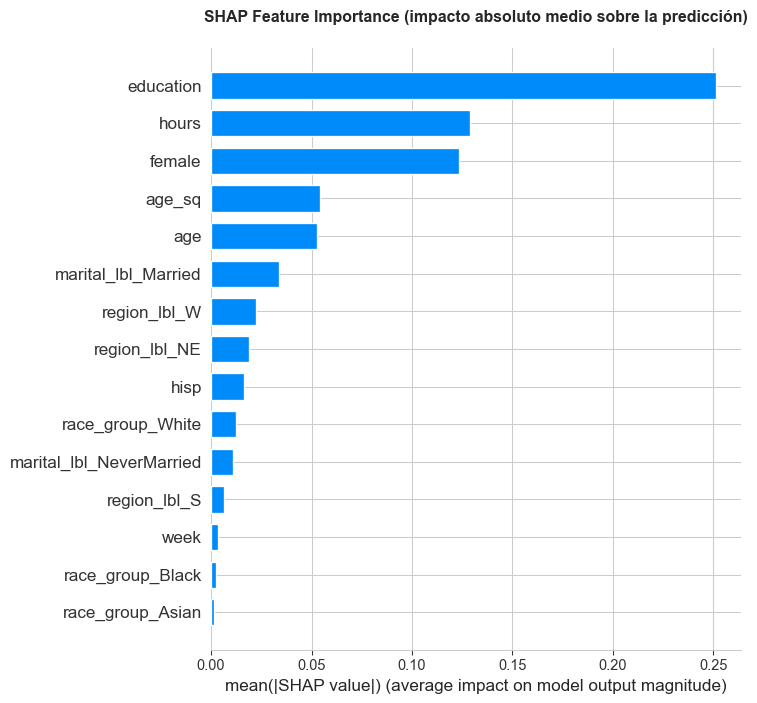

In [66]:
# 7.3.b SHAP bar plot — importancia agregada
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance (impacto absoluto medio sobre la predicción)',
          fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

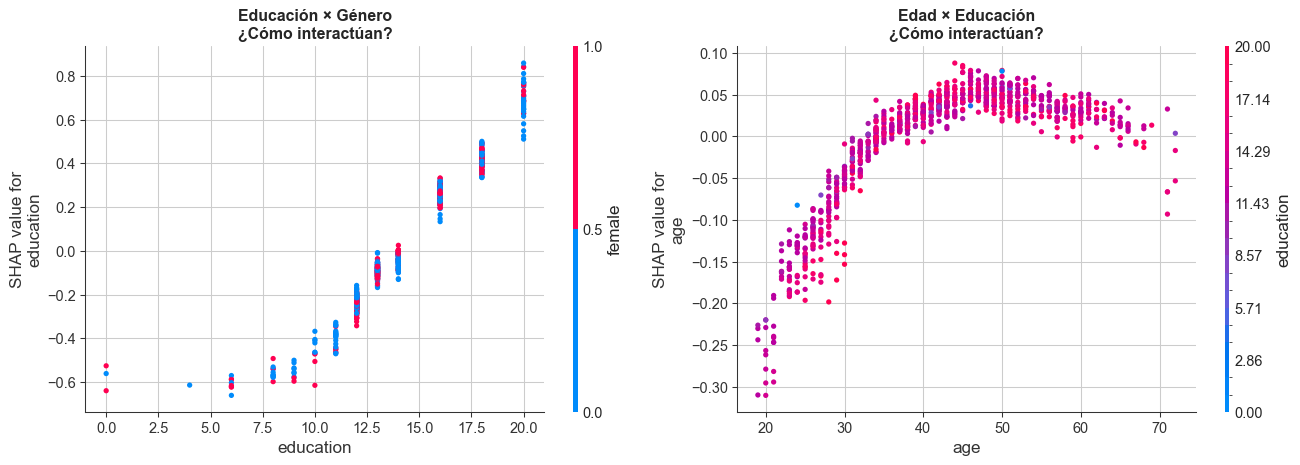

In [67]:
# 7.3.c SHAP dependence plots — interacciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot('education', shap_values, X_sample, interaction_index='female',
                     ax=axes[0], show=False)
axes[0].set_title('Educación × Género\n¿Cómo interactúan?', fontweight='bold')

shap.dependence_plot('age', shap_values, X_sample, interaction_index='education',
                     ax=axes[1], show=False)
axes[1].set_title('Edad × Educación\n¿Cómo interactúan?', fontweight='bold')

plt.tight_layout()
plt.show()

**SHAP dependence plots** muestran **interacciones** entre variables. Por ejemplo, en el primer panel podemos ver si la educación afecta de forma diferente a hombres y mujeres.


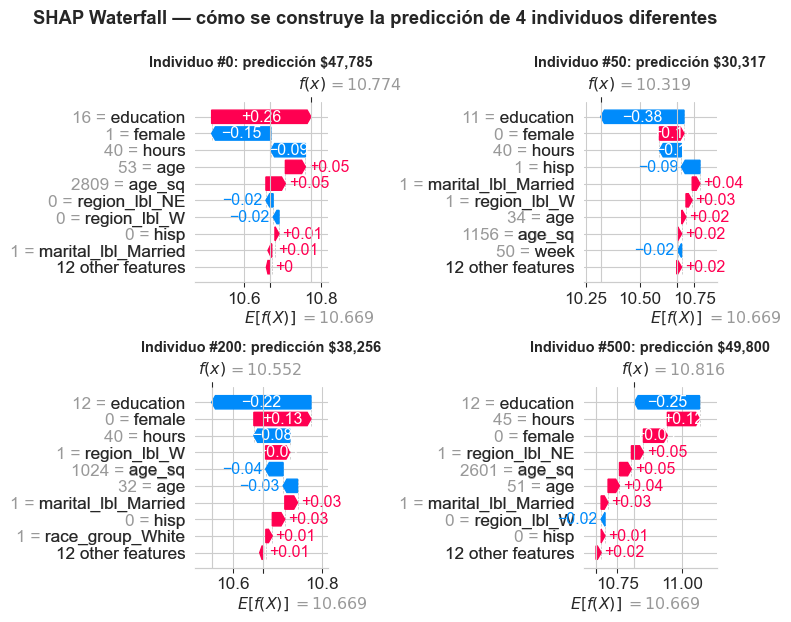

In [68]:
# 7.3.d Explicación local — varios individuos contrastados
indices_to_explain = [0, 50, 200, 500]  # Cuatro individuos distintos

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax_idx, idx in enumerate(indices_to_explain):
    individuo = X_sample.iloc[idx]
    pred = rf.predict(individuo.values.reshape(1,-1))[0]

    shap_explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=expected_val,
        data=X_sample.iloc[idx].values,
        feature_names=X_sample.columns.tolist()
    )

    plt.sca(axes[ax_idx])
    shap.plots.waterfall(shap_explanation, max_display=10, show=False)
    axes[ax_idx].set_title(f'Individuo #{idx}: predicción ${np.exp(pred):,.0f}',
                            fontweight='bold', fontsize=11)

plt.suptitle('SHAP Waterfall — cómo se construye la predicción de 4 individuos diferentes',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Para qué sirven los waterfalls en negocio:** son la respuesta "defendible" cuando un colaborador o cliente pregunta *"¿por qué este modelo me asignó este nivel?"*. Cada barra dice exactamente cuánto contribuyó cada variable.


## 8. Traducción a estrategia (Insight → Decisión → Acción → Feedback)

### 8.1 Insights principales

Los modelos convergen en estos drivers de ingreso:

1. **Educación** — driver más fuerte. Cada año extra ~7-12% más de ingresos. Premium se acelera en niveles universitarios.
2. **Horas y semanas trabajadas** — segundo y tercer driver.
3. **Edad** — no lineal: sube hasta los 50s, después se aplana (`age²` lo captura).
4. **Género** — coeficiente negativo y significativo **controlando por todo lo demás**. Aquí entra "inequality vs inequity".
5. **Estado civil (married)** — "marriage premium" documentado.
6. **Region** — moderada; NE y W más altos.
7. **Hispanic, race** — efectos significativos aunque menores que educación.
8. **Union** — sindicalización se asocia con ingresos algo más altos.

### 8.2 Decisiones (palancas accionables)

**HR / Total Rewards:**
- Auditar brechas salariales controlando por educación, antigüedad y rol.
- Diseñar bandas salariales explícitas para reducir discrecionalidad.
- Programas de patrocinio/mentoría para grupos infrarrepresentados.

**Marketing:**
- Scoring de poder adquisitivo para segmentación premium.

**Política pública:**
- Inversión en educación con retornos altos y consistentes.
- Programas anti-discriminación basados en evidencia.

### 8.3 Acciones (operacionalización)

Aunque es regresión, podemos definir umbrales accionables:
- **Marketing:** "ingreso predicho > $80,000" → segmento premium. El umbral τ se elige por costo de campaña y revenue esperado (la función de costo de la nota IPADE).
- **HR:** "|salario real − salario predicho| / predicho > 15%" → caso a revisar (posible inequidad o top performer infravalorado).

### 8.4 Feedback

- Reentrenar anualmente con CPS-ASEC nuevo.
- Monitorear drift: ¿cambian los drivers con el tiempo?
- A/B test cualquier intervención de HR, midiendo uplift en compensación 2-3 años.

### 8.5 Limitaciones éticas

- **NO es causal.** El coeficiente negativo de `female` no prueba discriminación directa: pueden mediar factores no observados (industria, ocupación, interrupciones de carrera, negociación). Pero **sí justifica investigar**.
- **R² ~0.35-0.41:** 55-65% de la varianza no la explica el modelo. Decisiones individuales no deben basarse solo en él.
- **Datos de 2009:** pueden no reflejar el mercado actual.
- **Fairness:** antes de usarlo para decisiones sobre personas, probar disparate impact y error parity.


## 9. Conclusiones gerenciales (formato IPADE)

### Objetivo
Entender qué factores demográficos y laborales explican las diferencias de ingreso en EE.UU. usando CPS marzo 2009.

### Método
Modelamos `log(earnings)` con 5 enfoques (OLS, Lasso, árbol, Random Forest, Gradient Boosting). Los hiperparámetros de los modelos de árbol se eligieron con búsqueda en validación cruzada (`GridSearchCV` / `RandomizedSearchCV`), usando `Pipeline` para evitar fugas de datos. El desempeño se evaluó con **validación cruzada anidada** —un estimado honesto que no se contamina con la elección de hiperparámetros— y los modelos finales se ajustaron sobre todos los datos para interpretarlos con coeficientes, feature importance, PDP y SHAP.

### Key Insights
1. **Educación, horas y semanas trabajadas** son los drivers más fuertes y accionables.
2. **Ser mujer se asocia con menor ingreso (~15-25%) controlando por todo lo demás** — señal de posible inequidad que merece investigación dedicada.
3. **Modelos lineales y de árbol llegan a R² similares**, incluso después de tunear los modelos de árbol — las relaciones son mayormente lineales y los coeficientes son interpretables con confianza.
4. **Asociaciones, no causas** — para acción debe combinarse con experimentos.

### Business Impact
- **HR:** detectar inequidades → reducir turnover, mejorar reputación, compliance.
- **Marketing:** scoring de poder adquisitivo para segmentación premium.
- **Política pública:** evidencia para inversión educativa y programas anti-discriminación.

### Next Steps
1. Replicar análisis con datos internos de la organización.
2. Auditar fairness (disparate impact, error parity).
3. Piloto: programa de mentoría dirigido a grupos infravalorados, medir uplift 24-36 meses.
4. Reentrenar y monitorear drift anualmente.
5. Combinar con datos cualitativos para triangular hallazgos.

---

*Notebook elaborado siguiendo la metodología de la nota técnica IPADE AD 25 eN 06 — "From Machine Learning Models to Strategy" (Herrera, Pensamiento & Rodríguez, 2025).*